**Feature Selection In Machine Learning**

In [ ]:
import pandas as pd
df = pd.read_csv("trainn.csv")

Applying Basic EDA on the given data 

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Checking for null values

In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Classifying features and target

In [8]:
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
X = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]
y = df["Survived"]

Removing null values from Age and Embarked 

In [11]:
X.loc[:, "Age"] = X["Age"].fillna(X["Age"].median())
X.loc[:, "Embarked"] = X["Embarked"].fillna(X["Embarked"].mode()[0])


In [12]:
X.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [13]:
X = pd.get_dummies(X, columns=["Sex", "Embarked"], drop_first=True)

In [14]:
X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


Applying Train_Test_Split Feature on x and y

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

Using **SelectKBest** feature for finding 5 best features which are suitable for model

In [16]:
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(score_func=f_classif, k=5)
X_train_selected = selector.fit_transform(X_train, y_train)

In [18]:
selected_features = X_train.columns[selector.get_support()]
print(selected_features)

Index(['Pclass', 'Parch', 'Fare', 'Sex_male', 'Embarked_S'], dtype='object')


In [19]:
scores = pd.Series(selector.scores_,index=X_train.columns).sort_values(ascending=False)
print(scores)

Sex_male      306.593249
Pclass         97.835853
Fare           58.314907
Embarked_S     23.546389
Parch           5.066904
Age             3.630391
Embarked_Q      0.705233
SibSp           0.484537
dtype: float64


**Method-2 Correlation**

In [20]:
correlation = X.corr()
print(correlation)

              Pclass       Age     SibSp     Parch      Fare  Sex_male  \
Pclass      1.000000 -0.339898  0.083081  0.018443 -0.549500  0.131900   
Age        -0.339898  1.000000 -0.233296 -0.172482  0.096688  0.081163   
SibSp       0.083081 -0.233296  1.000000  0.414838  0.159651 -0.114631   
Parch       0.018443 -0.172482  0.414838  1.000000  0.216225 -0.245489   
Fare       -0.549500  0.096688  0.159651  0.216225  1.000000 -0.182333   
Sex_male    0.131900  0.081163 -0.114631 -0.245489 -0.182333  1.000000   
Embarked_Q  0.221009 -0.031415 -0.026354 -0.081228 -0.117216 -0.074115   
Embarked_S  0.074053 -0.006729  0.068734  0.060814 -0.162184  0.119224   

            Embarked_Q  Embarked_S  
Pclass        0.221009    0.074053  
Age          -0.031415   -0.006729  
SibSp        -0.026354    0.068734  
Parch        -0.081228    0.060814  
Fare         -0.117216   -0.162184  
Sex_male     -0.074115    0.119224  
Embarked_Q    1.000000   -0.499421  
Embarked_S   -0.499421    1.000000  


Installing seaborn for visualization

In [23]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

Graphical representation 

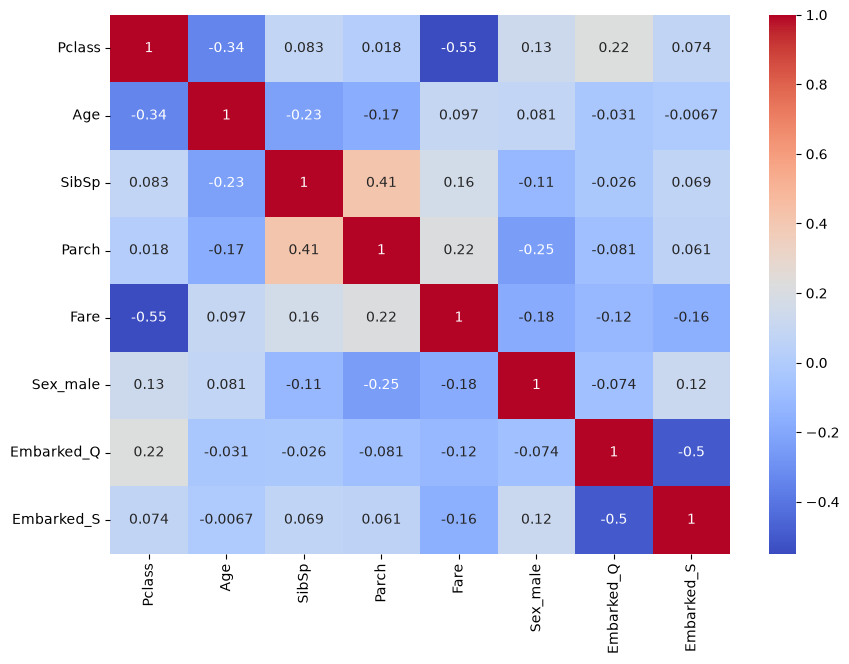

In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.show()

In [ ]:
corr_matrix = X.corr().abs()
upper = corr_matrix.where(
    ~__import__("numpy").tril(
        __import__("numpy").ones(corr_matrix.shape), k=0
    ).astype(bool)
)
print(upper)

            Pclass       Age     SibSp     Parch      Fare  Sex_male  \
Pclass         NaN  0.339898  0.083081  0.018443  0.549500  0.131900   
Age            NaN       NaN  0.233296  0.172482  0.096688  0.081163   
SibSp          NaN       NaN       NaN  0.414838  0.159651  0.114631   
Parch          NaN       NaN       NaN       NaN  0.216225  0.245489   
Fare           NaN       NaN       NaN       NaN       NaN  0.182333   
Sex_male       NaN       NaN       NaN       NaN       NaN       NaN   
Embarked_Q     NaN       NaN       NaN       NaN       NaN       NaN   
Embarked_S     NaN       NaN       NaN       NaN       NaN       NaN   

            Embarked_Q  Embarked_S  
Pclass        0.221009    0.074053  
Age           0.031415    0.006729  
SibSp         0.026354    0.068734  
Parch         0.081228    0.060814  
Fare          0.117216    0.162184  
Sex_male      0.074115    0.119224  
Embarked_Q         NaN    0.499421  
Embarked_S         NaN         NaN  
